In [1]:
!pip install -q networkx matplotlib seaborn pandas tabulate

In [2]:
import math
import itertools
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from matplotlib.patches import Patch

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

In [4]:
CONSTANTS = ["Alice", "Bob", "Charlie", "Dave", "Alpha", "Beta", "Dev1", "Dev2"]

FACTS = {
    # Relational & Entity Predicates
    "AssignedTo": {("Alice", "Alpha"), ("Bob", "Alpha"), ("Charlie", "Beta"), ("Dave", "Beta")},
    "Manages": {("Alpha", "Dev1"), ("Beta", "Dev2")},
    "UsesDevice": {("Alice", "Dev1"), ("Bob", "Dev1"), ("Charlie", "Dev2"), ("Dave", "Dev2")},
    "AccessesProject": {("Dev1", "Dev1"), ("Dev2", "Dev2")}, # simplified mapping: device -> project
    "Unvetted": {("Alice",), ("Dave",)},
    "HasMalware": {("Dev2",)}
}

ARITY = {
    "AssignedTo": 2,
    "Manages": 2,
    "UsesDevice": 2,
    "AccessesProject": 2,
    "Unvetted": 1,
    "HasMalware": 1
}

TARGET = "SecurityRisk"
TARGET_VARS = ("x", "y")


def is_true(pred, args):
    """Closed world lookup."""
    return tuple(args) in FACTS[pred]


def ground_truth(x, y):
    """x is a security risk to project y."""
    # Path 1: Unvetted user on a team managing project y
    if is_true("Unvetted", (x,)):
        for z in CONSTANTS:
            if is_true("AssignedTo", (x, z)) and is_true("Manages", (z, y)):
                return True

    # Path 2: User operates a malware-infected device accessing project y
    for z in CONSTANTS:
        if is_true("UsesDevice", (x, z)) and is_true("HasMalware", (z,)) and is_true("Manages", ("Beta", y)):
            return True

    return False


ALL_PAIRS = [(a, b) for a in CONSTANTS for b in CONSTANTS]
POSITIVES = [p for p in ALL_PAIRS if ground_truth(*p)]
NEGATIVES = [p for p in ALL_PAIRS if not ground_truth(*p)]

print("=" * 78)
print(" FOIL : FIRST ORDER INDUCTIVE LEARNER ".center(78, "="))
print("=" * 78)
print("\nConstants (%d) : %s" % (len(CONSTANTS), ", ".join(CONSTANTS)))
print("Total possible %s(x,y) pairs : %d" % (TARGET, len(ALL_PAIRS)))
print("Positive examples : %d  -> %s" % (len(POSITIVES), POSITIVES))
print("Negative examples : %d" % len(NEGATIVES))

kb_rows = []
for p in list(FACTS.keys()):
    for t in sorted(FACTS[p]):
        kb_rows.append([p, ", ".join(t)])
print("\nBACKGROUND KNOWLEDGE BASE")
print(tabulate(kb_rows, headers=["Predicate", "Arguments"], tablefmt="grid"))

==================== FOIL : FIRST ORDER INDUCTIVE LEARNER ====================

Constants (8) : Alice, Bob, Charlie, Dave, Alpha, Beta, Dev1, Dev2
Total possible SecurityRisk(x,y) pairs : 64
Positive examples : 3  -> [('Alice', 'Dev1'), ('Charlie', 'Dev2'), ('Dave', 'Dev2')]
Negative examples : 61

BACKGROUND KNOWLEDGE BASE
+-----------------+---------------+
| Predicate       | Arguments     |
+=================+===============+
| AssignedTo      | Alice, Alpha  |
+-----------------+---------------+
| AssignedTo      | Bob, Alpha    |
+-----------------+---------------+
| AssignedTo      | Charlie, Beta |
+-----------------+---------------+
| AssignedTo      | Dave, Beta    |
+-----------------+---------------+
| Manages         | Alpha, Dev1   |
+-----------------+---------------+
| Manages         | Beta, Dev2    |
+-----------------+---------------+
| UsesDevice      | Alice, Dev1   |
+-----------------+---------------+
| UsesDevice      | Bob, Dev1     |
+-----------------+-------

In [5]:
def lit_str(lit):
    neg, pred, vs = lit
    return ("not " if neg else "") + "%s(%s)" % (pred, ",".join(vs))


def rule_str(body):
    head = "%s(%s)" % (TARGET, ",".join(TARGET_VARS))
    if not body:
        return head + " :- "
    return head + " :- " + ", ".join(lit_str(l) for l in body)


def extend_bindings(bindings, lit):
    """Apply one literal to a binding table."""
    neg, pred, vs = lit
    new_bindings, parents = [], []

    for i, b in enumerate(bindings):
        if neg:
            args = tuple(b[v] for v in vs)
            if not is_true(pred, args):
                new_bindings.append(dict(b))
                parents.append(i)
        else:
            for fact in FACTS[pred]:
                nb = dict(b)
                ok = True
                for var, val in zip(vs, fact):
                    if var in nb:
                        if nb[var] != val:
                            ok = False
                            break
                    else:
                        nb[var] = val
                if ok:
                    new_bindings.append(nb)
                    parents.append(i)
    return new_bindings, parents


def evaluate_rule(body, pairs):
    """Which (x,y) pairs does this rule body cover?"""
    bindings = [{"x": a, "y": b} for (a, b) in pairs]
    for lit in body:
        bindings, _ = extend_bindings(bindings, lit)
    return {(b["x"], b["y"]) for b in bindings}


def split_bindings(bindings, pos_set):
    """Return (positive_binding_indices, negative_binding_indices)."""
    pos_idx = [i for i, b in enumerate(bindings) if (b["x"], b["y"]) in pos_set]
    neg_idx = [i for i, b in enumerate(bindings) if (b["x"], b["y"]) not in pos_set]
    return pos_idx, neg_idx

In [6]:
NEW_VAR_POOL = ["z", "w", "v"]
ENFORCE_LINKAGE = True
USE_NEGATION = False


def has_dangling_variable(body):
    """True if some body-only variable has been used just once so far."""
    counts = {}
    for _, _, vs in body:
        for v in vs:
            counts[v] = counts.get(v, 0) + 1
    return any(v not in TARGET_VARS and c < 2 for v, c in counts.items())


def candidate_literals(body):
    used = set(TARGET_VARS)
    for _, _, vs in body:
        used.update(vs)
    fresh = next(v for v in NEW_VAR_POOL if v not in used)
    allow_new = not (ENFORCE_LINKAGE and has_dangling_variable(body))
    pool = sorted(used) + ([fresh] if allow_new else [])
    existing = set(used)

    cands = []
    for pred, k in ARITY.items():
        for combo in itertools.product(pool, repeat=k):
            if not any(v in existing for v in combo):
                continue
            if combo.count(fresh) > 1:
                continue
            for neg in ((False, True) if USE_NEGATION else (False,)):
                if neg and fresh in combo:
                    continue
                lit = (neg, pred, combo)
                if lit not in body:
                    cands.append(lit)
    return cands


def n_new_vars(lit, body):
    used = set(TARGET_VARS)
    for _, _, vs in body:
        used.update(vs)
    return len([v for v in set(lit[2]) if v not in used])

In [7]:
def foil_gain(p0, n0, p1, n1, t):
    if p1 == 0 or p0 == 0 or t == 0:
        return float("-inf")
    return t * (math.log2(p1 / (p1 + n1)) - math.log2(p0 / (p0 + n0)))

In [8]:
TRACE = []
RULES = []
ROUND_LOG = []


def learn_one_rule(pos, neg, round_no):
    pos_set = set(pos)
    universe = list(pos) + list(neg)
    body = []
    bindings = [{"x": a, "y": b} for (a, b) in universe]
    pos_idx, neg_idx = split_bindings(bindings, pos_set)
    p0, n0 = len(pos_idx), len(neg_idx)

    step = 0
    while n0 > 0 and step < 6:
        step += 1
        scored = []
        for lit in candidate_literals(body):
            nb, parents = extend_bindings(bindings, lit)
            npos, nneg = split_bindings(nb, pos_set)
            p1, n1 = len(npos), len(nneg)
            surviving_parents = {parents[i] for i in npos}
            t = len(surviving_parents & set(pos_idx))
            g = foil_gain(p0, n0, p1, n1, t)
            scored.append(dict(round=round_no, step=step, literal=lit_str(lit),
                               p1=p1, n1=n1, t=t, gain=g,
                               newvars=n_new_vars(lit, body)))

        scored.sort(key=lambda d: (-d["gain"], d["newvars"], d["literal"]))
        TRACE.extend(scored)

        best = scored[0]
        if best["gain"] == float("-inf"):
            break
        best_lit = next(l for l in candidate_literals(body)
                        if lit_str(l) == best["literal"])

        print("\n  Step %d : rule before -> %s   (p=%d, n=%d)"
              % (step, rule_str(body), p0, n0))
        top = pd.DataFrame([s for s in scored if s["gain"] > float("-inf")]
                           )[["literal", "p1", "n1", "t", "gain"]].head(6)
        top["gain"] = top["gain"].round(3)
        print(tabulate(top, headers=["candidate literal", "p1", "n1", "t", "FOIL_Gain"],
                       tablefmt="simple", showindex=False))
        print("  --> CHOSEN : %s" % best["literal"])

        body.append(best_lit)
        bindings, _ = extend_bindings(bindings, best_lit)
        pos_idx, neg_idx = split_bindings(bindings, pos_set)
        p0, n0 = len(pos_idx), len(neg_idx)

    return body, p0, n0


def foil(positives, negatives):
    remaining = list(positives)
    round_no = 0
    while remaining:
        round_no += 1
        print("\n" + "=" * 78)
        print(" OUTER LOOP ROUND %d : %d positive example(s) still uncovered"
              % (round_no, len(remaining)))
        print("=" * 78)
        body, p_end, n_end = learn_one_rule(remaining, negatives, round_no)
        covered = evaluate_rule(body, ALL_PAIRS) & set(remaining)
        if not covered:
            print("  ! rule covers nothing new - stopping to avoid infinite loop")
            break
        RULES.append(body)
        ROUND_LOG.append(dict(round=round_no, rule=rule_str(body),
                              literals=len(body), covered=len(covered),
                              remaining_before=len(remaining),
                              final_p=p_end, final_n=n_end))
        print("\n  LEARNED RULE %d : %s" % (round_no, rule_str(body)))
        print("  Covers positives : %s" % sorted(covered))
        remaining = [p for p in remaining if p not in covered]
    return RULES


foil(POSITIVES, NEGATIVES)

print("\n" + "=" * 78)
print(" FINAL LEARNED RULE SET ".center(78, "="))
print("=" * 78)
for i, r in enumerate(RULES, 1):
    print("  R%d : %s" % (i, rule_str(r)))

trace_df = pd.DataFrame(TRACE)
trace_df = trace_df[trace_df.gain > float("-inf")].reset_index(drop=True)


 OUTER LOOP ROUND 1 : 3 positive example(s) still uncovered

  Step 1 : rule before -> SecurityRisk(x,y) :-    (p=3, n=61)
candidate literal       p1    n1    t    FOIL_Gain
--------------------  ----  ----  ---  -----------
UsesDevice(x,y)          3     1    3           12
AccessesProject(y,y)     3    13    3            6
AccessesProject(y,z)     3    13    3            6
AccessesProject(z,y)     3    13    3            6
Manages(z,y)             3    13    3            6
UsesDevice(z,y)          6    26    3            6
  --> CHOSEN : UsesDevice(x,y)

  Step 2 : rule before -> SecurityRisk(x,y) :- UsesDevice(x,y)   (p=3, n=1)
candidate literal       p1    n1    t    FOIL_Gain
--------------------  ----  ----  ---  -----------
HasMalware(y)            2     0    2         0.83
Unvetted(x)              2     0    2         0.83
AccessesProject(y,y)     3     1    3         0
AccessesProject(y,z)     3     1    3         0
AccessesProject(z,y)     3     1    3         0
AssignedTo(x

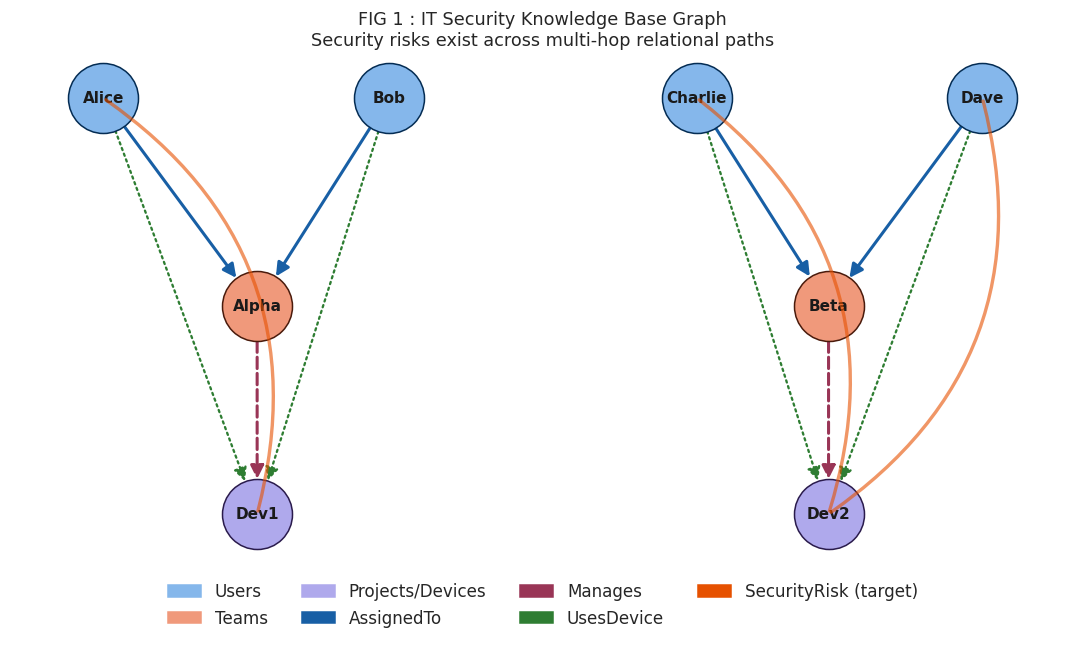

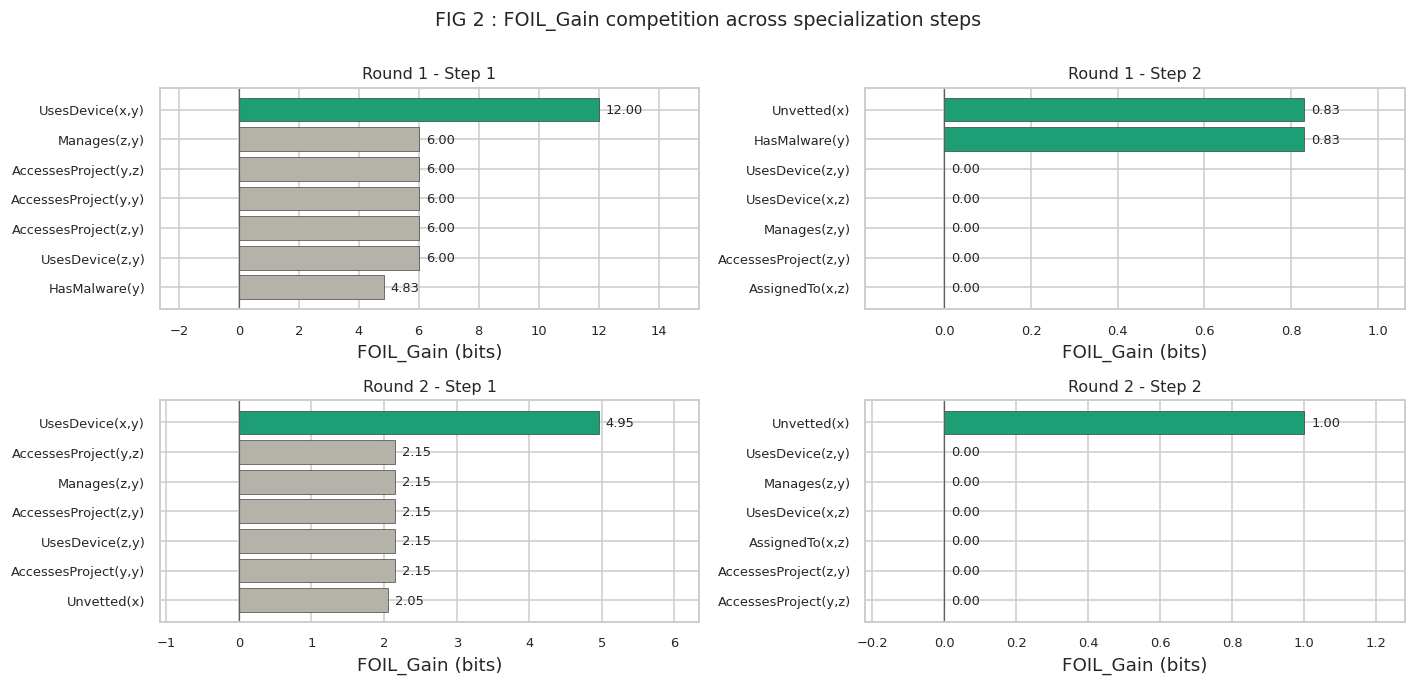

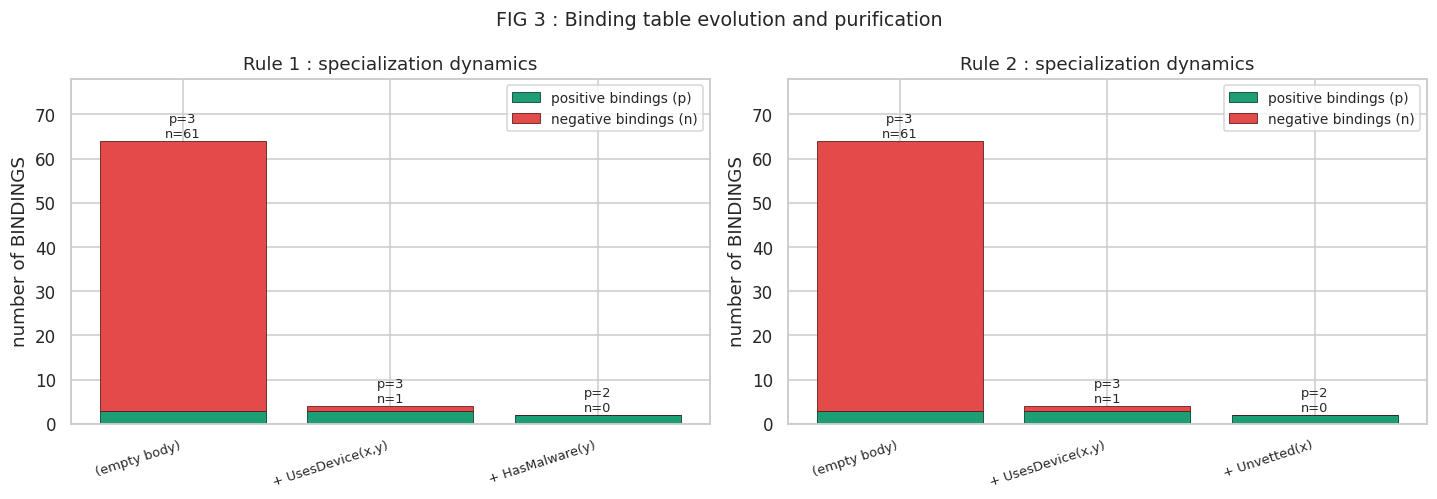

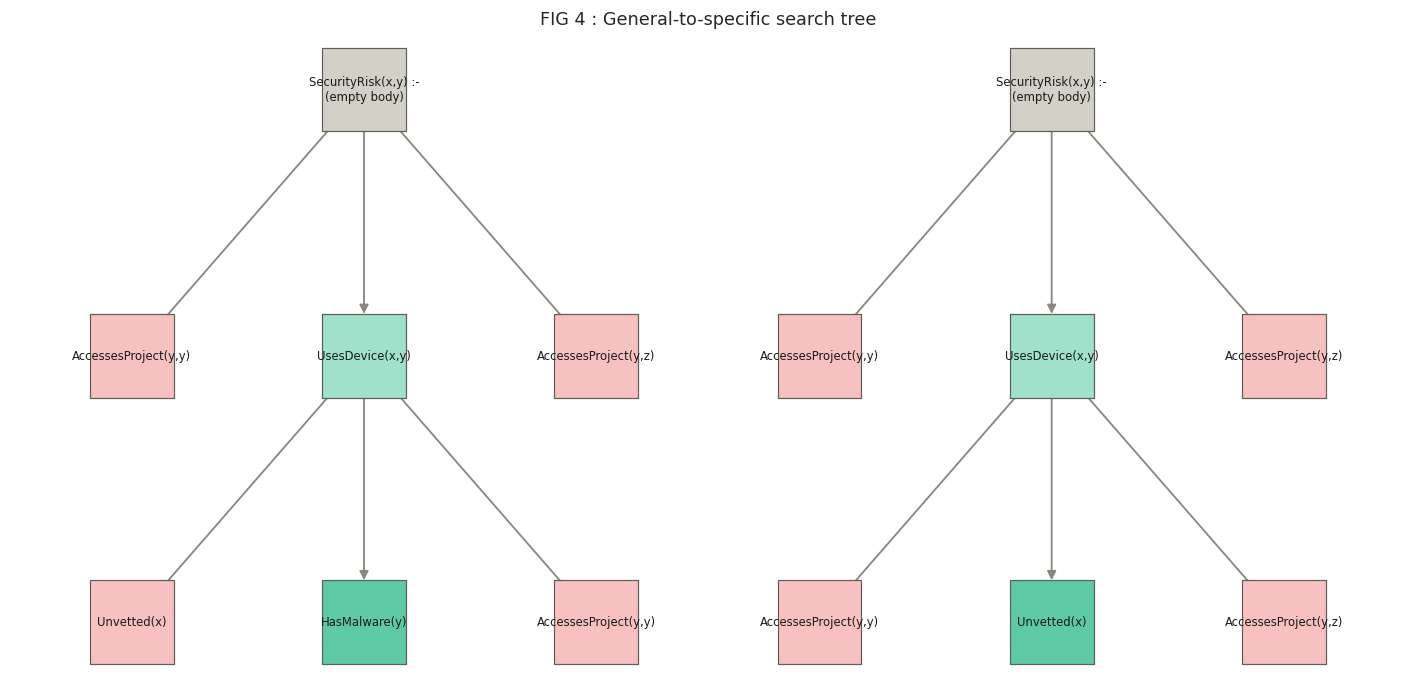

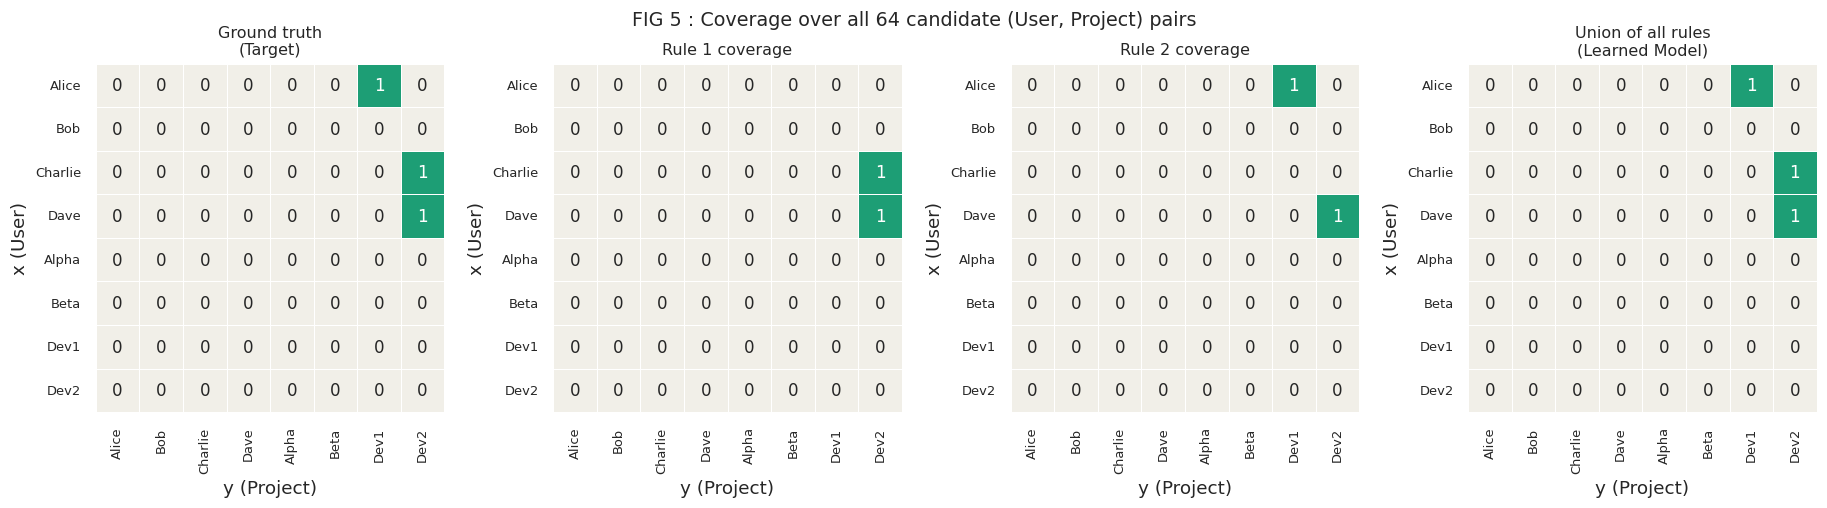

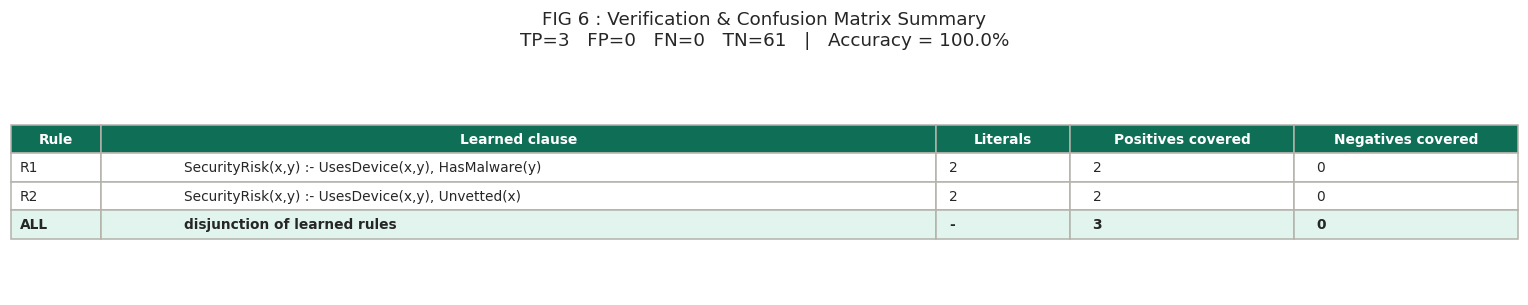

In [9]:
G = nx.DiGraph()
G.add_nodes_from(CONSTANTS)
for a, b in FACTS["AssignedTo"]:
    G.add_edge(a, b, rel="AssignedTo")
for a, b in FACTS["Manages"]:
    G.add_edge(a, b, rel="Manages")
for a, b in FACTS["UsesDevice"]:
    G.add_edge(a, b, rel="UsesDevice")

pos_layout = {
    "Alice": (-2.0, 2), "Bob": (-0.7, 2), "Charlie": (0.7, 2), "Dave": (2.0, 2),
    "Alpha": (-1.3, 1), "Beta": (1.3, 1),
    "Dev1": (-1.3, 0), "Dev2": (1.3, 0)
}

fig, ax = plt.subplots(figsize=(10, 6))
users = ["Alice", "Bob", "Charlie", "Dave"]
teams = ["Alpha", "Beta"]
projects = ["Dev1", "Dev2"]

nx.draw_networkx_nodes(G, pos_layout, nodelist=users, node_color="#85B7EB",
                       node_size=2100, edgecolors="#042C53", ax=ax)
nx.draw_networkx_nodes(G, pos_layout, nodelist=teams, node_color="#F0997B",
                       node_size=2100, edgecolors="#4A1B0C", ax=ax)
nx.draw_networkx_nodes(G, pos_layout, nodelist=projects, node_color="#AFA9EC",
                       node_size=2100, edgecolors="#2A1B4C", ax=ax)
nx.draw_networkx_labels(G, pos_layout, font_size=10, font_weight="bold", ax=ax)

a_edges = [(a, b) for a, b, d in G.edges(data=True) if d["rel"] == "AssignedTo"]
m_edges = [(a, b) for a, b, d in G.edges(data=True) if d["rel"] == "Manages"]
u_edges = [(a, b) for a, b, d in G.edges(data=True) if d["rel"] == "UsesDevice"]

nx.draw_networkx_edges(G, pos_layout, edgelist=a_edges, edge_color="#185FA5",
                       width=2, arrowsize=18, node_size=2100, ax=ax)
nx.draw_networkx_edges(G, pos_layout, edgelist=m_edges, edge_color="#993556",
                       width=2, style="dashed", arrowsize=18, node_size=2100, ax=ax)
nx.draw_networkx_edges(G, pos_layout, edgelist=u_edges, edge_color="#2E7D32",
                       width=1.5, style="dotted", arrowsize=18, node_size=2100, ax=ax)

for (a, b) in POSITIVES:
    ax.annotate("", xy=pos_layout[a], xytext=pos_layout[b],
                arrowprops=dict(arrowstyle="-", color="#E65100",
                                lw=2.2, alpha=0.6,
                                connectionstyle="arc3,rad=0.35"))

ax.legend(handles=[Patch(color="#85B7EB", label="Users"),
                   Patch(color="#F0997B", label="Teams"),
                   Patch(color="#AFA9EC", label="Projects/Devices"),
                   Patch(color="#185FA5", label="AssignedTo"),
                   Patch(color="#993556", label="Manages"),
                   Patch(color="#2E7D32", label="UsesDevice"),
                   Patch(color="#E65100", label="SecurityRisk (target)")],
          loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4, frameon=False)
ax.set_title("FIG 1 : IT Security Knowledge Base Graph\n"
             "Security risks exist across multi-hop relational paths", fontsize=11.5)
ax.axis("off")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------- FIGURE 2
steps = trace_df.groupby(["round", "step"]).size().index.tolist()
ncol = 2
nrow = int(math.ceil(len(steps) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.1 * nrow))
axes = np.array(axes).reshape(-1)

for ax, (rnd, stp) in zip(axes, steps):
    sub = trace_df[(trace_df["round"] == rnd) & (trace_df["step"] == stp)]
    sub = sub.sort_values("gain", ascending=True).tail(7)
    hi, lo = sub["gain"].max(), min(0.0, sub["gain"].min())
    span = max(hi - lo, 0.5)
    colors = ["#1D9E75" if g == hi else ("#E24B4A" if g < 0 else "#B4B2A9")
              for g in sub["gain"]]
    ax.barh(sub["literal"], sub["gain"], color=colors, edgecolor="#2C2C2A", lw=0.4)
    for yi, g in enumerate(sub["gain"]):
        off = 0.02 * span
        ax.text(g + off if g >= 0 else g - off, yi, "%.2f" % g,
                va="center", ha="left" if g >= 0 else "right", fontsize=8.5)
    ax.axvline(0, color="#5F5E5A", lw=0.8)
    ax.set_title("Round %d - Step %d" % (rnd, stp), fontsize=10.5)
    ax.set_xlabel("FOIL_Gain (bits)")
    ax.set_xlim(lo - 0.22 * span, hi + 0.28 * span)
    ax.tick_params(labelsize=8.5)

for ax in axes[len(steps):]:
    ax.axis("off")

fig.suptitle("FIG 2 : FOIL_Gain competition across specialization steps", fontsize=12.5, y=1.0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------- FIGURE 3
prog = []
for r_i, body in enumerate(RULES, 1):
    universe = ALL_PAIRS
    pos_set = set(POSITIVES)
    bindings = [{"x": a, "y": b} for (a, b) in universe]
    pi, ni = split_bindings(bindings, pos_set)
    prog.append(dict(round=r_i, step=0, label="(empty body)",
                      p=len(pi), n=len(ni)))
    for s_i, lit in enumerate(body, 1):
        bindings, _ = extend_bindings(bindings, lit)
        pi, ni = split_bindings(bindings, pos_set)
        prog.append(dict(round=r_i, step=s_i, label=lit_str(lit),
                          p=len(pi), n=len(ni)))
prog_df = pd.DataFrame(prog)

fig, axes = plt.subplots(1, len(RULES), figsize=(6.6 * len(RULES), 4.6), squeeze=False)
for ax, r_i in zip(axes[0], sorted(prog_df["round"].unique())):
    sub = prog_df[prog_df["round"] == r_i]
    idx = np.arange(len(sub))
    ax.bar(idx, sub["p"], color="#1D9E75", label="positive bindings (p)", edgecolor="#04342C", lw=0.5)
    ax.bar(idx, sub["n"], bottom=sub["p"], color="#E24B4A", label="negative bindings (n)", edgecolor="#501313", lw=0.5)
    for i, (p, n) in enumerate(zip(sub["p"], sub["n"])):
        ax.text(i, p + n + 0.8, "p=%d\nn=%d" % (p, n), ha="center", fontsize=8.5)
    ax.set_xticks(idx)
    ax.set_xticklabels(["+ " + l if s > 0 else l
                        for l, s in zip(sub["label"], sub["step"])],
                       rotation=18, ha="right", fontsize=8.5)
    ax.set_ylabel("number of BINDINGS")
    ax.set_title("Rule %d : specialization dynamics" % r_i)
    ax.legend(fontsize=9)
    ax.set_ylim(0, (sub["p"] + sub["n"]).max() * 1.22)

fig.suptitle("FIG 3 : Binding table evolution and purification", fontsize=12.5)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------- FIGURE 4
T = nx.DiGraph()
labels, colors, tpos = {}, {}, {}
y_gap = 1.0

for r_i, body in enumerate(RULES, 1):
    x_base = (r_i - 1) * 4.0
    root = "R%d_s0" % r_i
    T.add_node(root)
    labels[root] = "%s(x,y) :-\n(empty body)" % TARGET
    colors[root] = "#D3D1C7"
    tpos[root] = (x_base, 0)

    prev = root
    for s_i, lit in enumerate(body, 1):
        sibs = trace_df[(trace_df["round"] == r_i) & (trace_df["step"] == s_i)]
        sibs = sibs.sort_values("gain", ascending=False).head(3)
        losers = [s for s in sibs["literal"] if s != lit_str(lit)][:2]
        for j, lname in enumerate(losers):
            nid = "R%d_s%d_x%d" % (r_i, s_i, j)
            T.add_node(nid)
            T.add_edge(prev, nid)
            labels[nid] = lname
            colors[nid] = "#F7C1C1"
            tpos[nid] = (x_base - 1.35 + j * 2.7, -s_i * y_gap)

        nid = "R%d_s%d" % (r_i, s_i)
        T.add_node(nid)
        T.add_edge(prev, nid)
        labels[nid] = lit_str(lit)
        colors[nid] = "#9FE1CB"
        tpos[nid] = (x_base, -s_i * y_gap)
        prev = nid
    colors[prev] = "#5DCAA5"

fig, ax = plt.subplots(figsize=(13, 6.4))
nx.draw_networkx_edges(T, tpos, edge_color="#888780", width=1.2,
                       arrows=True, arrowsize=12, node_size=3000, ax=ax)
nx.draw_networkx_nodes(T, tpos, node_color=[colors[n] for n in T.nodes()],
                       node_size=3000, node_shape="s",
                       edgecolors="#5F5E5A", linewidths=0.8, ax=ax)
nx.draw_networkx_labels(T, tpos, labels=labels, font_size=7.6, ax=ax)
ax.set_title("FIG 4 : General-to-specific search tree", fontsize=11.5)
ax.axis("off")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------- FIGURE 5
n_c = len(CONSTANTS)
truth = np.array([[1 if ground_truth(a, b) else 0 for b in CONSTANTS]
                  for a in CONSTANTS])

cov_maps, titles = [truth], ["Ground truth\n(Target)"]
union = np.zeros_like(truth)
for i, body in enumerate(RULES, 1):
    cov = evaluate_rule(body, ALL_PAIRS)
    m = np.array([[1 if (a, b) in cov else 0 for b in CONSTANTS]
                  for a in CONSTANTS])
    union = np.maximum(union, m)
    cov_maps.append(m)
    titles.append("Rule %d coverage" % i)
cov_maps.append(union)
titles.append("Union of all rules\n(Learned Model)")

fig, axes = plt.subplots(1, len(cov_maps), figsize=(4.2 * len(cov_maps), 4.4))
for ax, m, t in zip(axes, cov_maps, titles):
    sns.heatmap(m, annot=True, fmt="d", cbar=False, square=True,
                cmap=sns.color_palette(["#F1EFE8", "#1D9E75"]),
                linewidths=0.6, linecolor="white",
                xticklabels=CONSTANTS, yticklabels=CONSTANTS, ax=ax)
    ax.set_title(t, fontsize=10.5)
    ax.set_xlabel("y (Project)")
    ax.set_ylabel("x (User)")
    ax.tick_params(labelsize=8.5)
fig.suptitle("FIG 5 : Coverage over all %d candidate (User, Project) pairs" % len(ALL_PAIRS), fontsize=12.5)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------- FIGURE 6
predicted = set()
for body in RULES:
    predicted |= evaluate_rule(body, ALL_PAIRS)

TP = len([p for p in ALL_PAIRS if p in predicted and ground_truth(*p)])
FP = len([p for p in ALL_PAIRS if p in predicted and not ground_truth(*p)])
FN = len([p for p in ALL_PAIRS if p not in predicted and ground_truth(*p)])
TN = len(ALL_PAIRS) - TP - FP - FN

rows = []
for i, body in enumerate(RULES, 1):
    cov = evaluate_rule(body, ALL_PAIRS)
    rows.append(["R%d" % i, rule_str(body), len(body),
                 len(cov & set(POSITIVES)), len(cov & set(NEGATIVES))])
rows.append(["ALL", "disjunction of learned rules", "-", TP, FP])

fig, ax = plt.subplots(figsize=(14, 1.05 + 0.62 * len(rows)))
ax.axis("off")
tbl = ax.table(cellText=rows,
               colLabels=["Rule", "Learned clause", "Literals",
                          "Positives covered", "Negatives covered"],
               cellLoc="left", loc="center",
               colWidths=[0.06, 0.56, 0.09, 0.15, 0.15])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.7)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#B4B2A9")
    if r == 0:
        cell.set_facecolor("#0F6E56")
        cell.set_text_props(color="white", weight="bold")
    elif r == len(rows):
        cell.set_facecolor("#E1F5EE")
        cell.set_text_props(weight="bold")
ax.set_title("FIG 6 : Verification & Confusion Matrix Summary\n"
             "TP=%d   FP=%d   FN=%d   TN=%d   |   Accuracy = %.1f%%"
             % (TP, FP, FN, TN, 100.0 * (TP + TN) / len(ALL_PAIRS)),
             fontsize=12, pad=16)
plt.tight_layout()
plt.show()

In [10]:
print("\n" + "=" * 78)
print(" ROUND-BY-ROUND SUMMARY ".center(78, "="))
print("=" * 78)
print(tabulate(pd.DataFrame(ROUND_LOG), headers="keys",
               tablefmt="grid", showindex=False))

print("\nCONFUSION MATRIX over all %d pairs" % len(ALL_PAIRS))
print(tabulate([["Actual POSITIVE", TP, FN], ["Actual NEGATIVE", FP, TN]],
               headers=["", "Predicted POS", "Predicted NEG"], tablefmt="grid"))


=========================== ROUND-BY-ROUND SUMMARY ===========================
+---------+-----------------------------------------------------+------------+-----------+--------------------+-----------+-----------+
|   round | rule                                                |   literals |   covered |   remaining_before |   final_p |   final_n |
+=========+=====================================================+============+===========+====================+===========+===========+
|       1 | SecurityRisk(x,y) :- UsesDevice(x,y), HasMalware(y) |          2 |         2 |                  3 |         2 |         0 |
+---------+-----------------------------------------------------+------------+-----------+--------------------+-----------+-----------+
|       2 | SecurityRisk(x,y) :- UsesDevice(x,y), Unvetted(x)   |          2 |         1 |                  1 |         1 |         0 |
+---------+-----------------------------------------------------+------------+-----------+--------------